File              ML algorithm       accuracy        Precision       Recall          F1-score        Time           
all_data          Naive Bayes        0.72            0.63            0.68            0.63            1.0339         


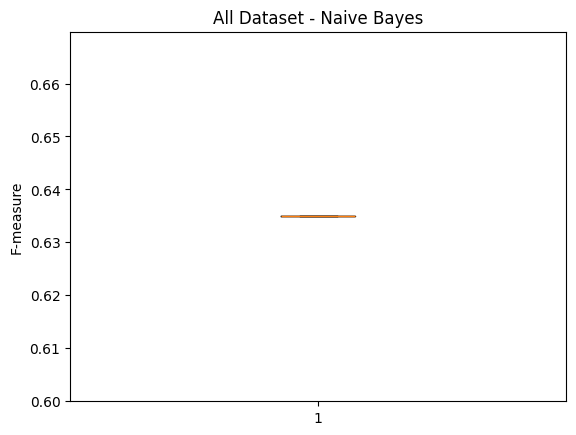

all_data          QDA                0.43            0.61            0.63            0.42            1.8268         


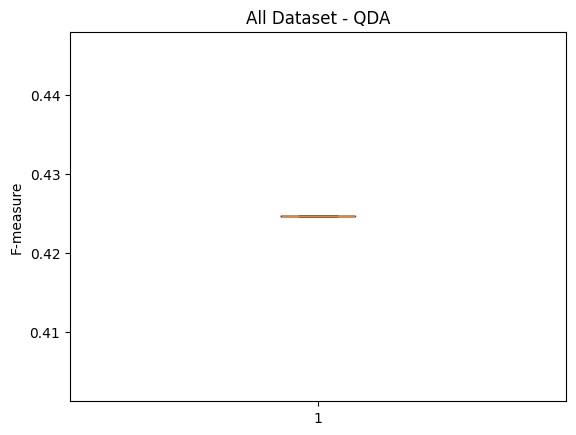

all_data          Random Forest      0.96            0.97            0.89            0.93            6.0474         


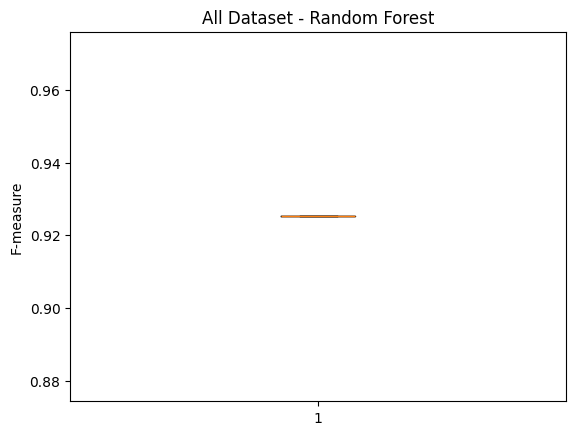

all_data          ID3                0.97            0.95            0.94            0.95            9.2582         


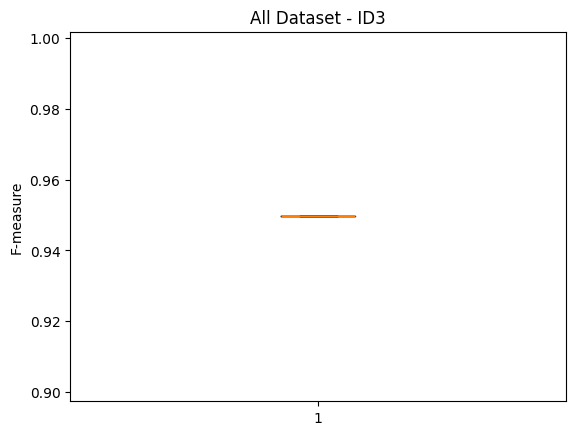

all_data          AdaBoost           0.98            0.98            0.96            0.97            110.2088       


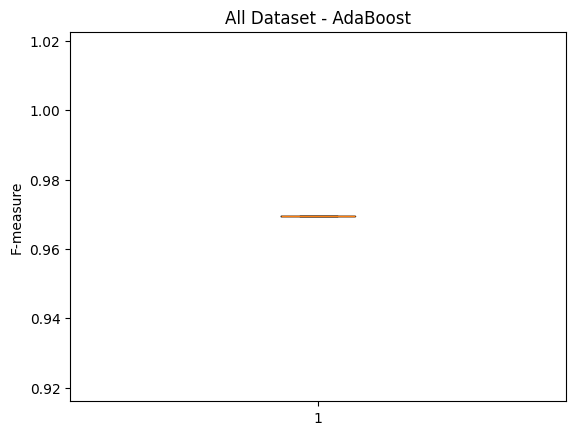

all_data          MLP                0.8             0.4             0.5             0.45            83.2479        


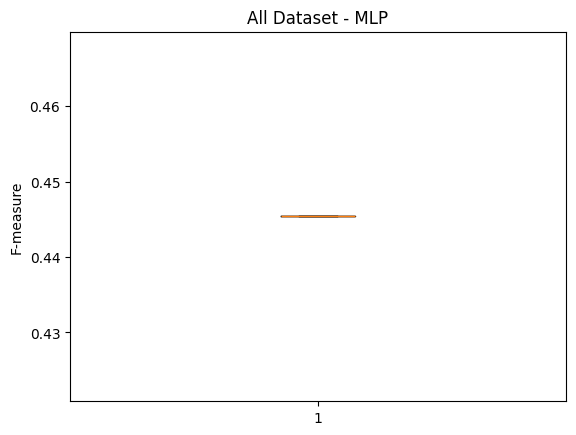

all_data          Nearest Neighbors  0.99            0.98            0.99            0.98            1053.4721      


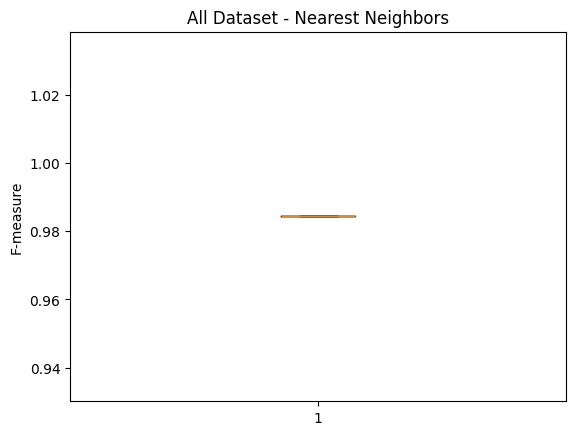

mission accomplished!
Total operation time: =  1269.2918570041656 seconds


In [1]:
##  the purpose of this program is to apply machine learning algorithms to the dataset and observe the performance of algorithms.
##  the algorithms used are:Naive Bayes, QDA, Random Forest, ID3, AdaBoost, MLP, Nearest Neighbors
##  As the program display output data include: file name, machine learning algorithm name, accuracy,Precision, Recall, F1-score,Time
##  the program will create a CSV file that prints the results and a folder containing graphics.

##  the some codes parts used for calculation and graphing are taken from the following site.
##  http://scikit-learn.org


from sklearn import metrics
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import average_precision_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score



            
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import os
import pandas as pd
import csv
import time
import warnings
import math
warnings.filterwarnings("ignore")


result="./results/results_2.csv" 
csv_files=["all_data.csv"]
path=""
repetition=1


def folder(f_name): 
    try:
        if not os.path.exists(f_name):
            os.makedirs(f_name)
    except OSError:
        print ("The folder could not be created!")

folder_name="./results/"
folder(folder_name)
folder_name="./results/result_graph_2/"
folder(folder_name)



ml_list={
"Naive Bayes":GaussianNB(),
"QDA":QDA(),
"Random Forest":RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
"ID3" :DecisionTreeClassifier(max_depth=5,criterion="entropy"),
"AdaBoost":AdaBoostClassifier(),
"MLP":MLPClassifier(hidden_layer_sizes=(13,13,13),max_iter=500),
"Nearest Neighbors":KNeighborsClassifier(3)}





features={"all_data":['Destination Port', 'Bwd Packet Length Std', 'Flow IAT Min', 'Flow IAT Mean', 'Flow IAT Std',
 'Fwd Packet Length Max', 'Bwd Packet Length Mean', 'Total Length of Fwd Packets', 'Total Backward Packets',
 'Fwd Packet Length Std', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean', 'Flow Duration',
 'Bwd Packet Length Max', 'Flow Bytes/s', 'Total Fwd Packets', 'Flow IAT Max', 
 'Flow Packets/s', 'Fwd Packet Length Min', 'label']}

seconds=time.time()






with open(result, "w", newline="",encoding="utf-8") as f:
    wrt = csv.writer(f)
    wrt.writerow(["File","ML algorithm","accuracy","Precision", "Recall" , "F1-score","Time"])




for j in csv_files: #this loop runs on the list containing the filenames.Operations are repeated for all attack files
    print ('%-17s %-17s  %-15s %-15s %-15s %-15s %-15s' % ("File","ML algorithm","accuracy","Precision", "Recall" , "F1-score","Time"))
    feature_list=list(features[j[0:-4]])
    df=pd.read_csv(path+j,usecols=feature_list)
    df=df.fillna(0)
    attack_or_not=[]
    for i in df["label"]: #it changes the normal label to "1" and the attack tag to "0" for use in the machine learning algorithm
        
        if i =="BENIGN":
            attack_or_not.append(1)
        else:
            attack_or_not.append(0)           
    df["label"]=attack_or_not

    
    y = df["label"] 
    del df["label"]
    feature_list.remove('label')
    X = df[feature_list]

    
    for ii in ml_list: 
        precision=[]
        recall=[]
        f1=[]
        accuracy=[]
        t_time=[]
        for i in range(repetition): # This loop allows cross-validation and machine learning algorithm to be repeated 10 times
            second=time.time()

            # cross-validation
            X_train, X_test, y_train, y_test = train_test_split(X, y,
                test_size = 0.20, random_state = repetition, stratify=y)


            #machine learning algorithm is applied in this section
            clf = ml_list[ii]                                                                  
            clf.fit(X_train, y_train)
            predict =clf.predict(X_test)
        
                
            

            f_1=f1_score(y_test, predict, average='macro')
            pr=precision_score(y_test, predict, average='macro')
            rc=recall_score(y_test, predict, average='macro')
            
            
            precision.append(float(pr))
            recall.append(float(rc))
            f1.append(float(f_1))
            accuracy.append(clf.score(X_test, y_test))
            t_time.append(float((time.time()-second)) )



            
        print ('%-17s %-17s  %-15s %-15s %-15s %-15s %-15s' % (j[0:-4],ii,str(round(np.mean(accuracy),2)),str(round(np.mean(precision),2)), 
            str(round(np.mean(recall),2)),str(round(np.mean(f1),2)),str(round(np.mean(t_time),4))))

        with open(result, "a", newline="",encoding="utf-8") as f: 
            wrt = csv.writer(f)
            for i in range(0,len(t_time)):
                wrt.writerow([j[0:-4],ii,accuracy[i],precision[i],recall[i],f1[i],t_time[i]])
   
     # In this section, Box graphics are created for the results of machine learning algorithms and saved in the feaure_graph folder.
        plt.boxplot(f1)
        plt.title("All Dataset - " +str(ii))
        plt.ylabel('F-measure')
        plt.savefig(folder_name+j[0:-4]+str(ii)+".pdf",bbox_inches='tight', orientation = 'portrait', format = 'pdf')
        plt.show()

print("mission accomplished!")
print("Total operation time: = ",time.time()- seconds ,"seconds")
